In [170]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from pathlib import Path
import spacy as sp
from spacy_cleaner import Cleaner
import spacy_cleaner
from spacy_cleaner.processing import removers, mutators

In [171]:
input_path=Path().resolve()/'input'

# Loading Dataa

In [172]:
training_data=pl.read_csv(input_path/'Corona_NLP_train.csv')

# Data Preprocessing

### Data Preprocessing pipeline:
1. clean missing values - Done
2. fix data types -Done
3. Text Cleaning -Done
4. tokenize the text of the target column -Done
5. remove stop words Done
6. Stemming words (Porter Stemmer) -Done

Note: Lemmatization is a very costly operation that takes minutes sometimes hours which is not suitable entirely for this project

In [173]:
# checking nulls
training_data.null_count()

UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
u32,u32,u32,u32,u32,u32
0,0,8590,0,0,0


null exists at location

We will impute those nulls with unknown value

In [174]:
training_data=training_data.with_columns(pl.col('Location').fill_null('unknown'))
training_data.null_count()

UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
u32,u32,u32,u32,u32,u32
0,0,0,0,0,0


In [175]:
# Converting the tweetat to polars datetime
training_data=training_data.with_columns(pl.col('TweetAt').str.to_date())

#### clean data and tokenize

In [176]:
core=sp.load('en_core_web_sm')

In [177]:
# preprocessing the data using spacy cleaners
# very slow method

pipeline=spacy_cleaner.Cleaner(
    core,
    removers.remove_email_token,
    removers.remove_stopword_token,
    removers.remove_url_token,
    mutators.mutate_lemma_token,
    removers.remove_punctuation_token)
def preprocess(text):
    # spliiting by @, then rejoining again and form strings
    text=[''.join(text.split('@'))]
    # define the pipeline for cleaning text
    return(pipeline.clean(text))    

In [178]:
# data=training_data.with_columns(pl.col('OriginalTweet').map_elements(lambda x: preprocess_faster(x), return_dtype=pl.String))
# data.select(pl.col('OriginalTweet')).to_series().to_list()

In [179]:
# Very Fast method --polars native
# S non whiteshapce character --s whitespace character 
def preprocess_pl_native(v):
    data = v.with_columns(
            pl.col('OriginalTweet').str.to_lowercase().str.replace_all(r'http\S+|www\S+|@|#', '').str.replace_all(r'[^\w\s]', ' ').str.replace_all(r'\s+', ' ').str.strip_chars())
    return data

In [180]:
training_data=training_data.pipe(preprocess_pl_native)

#### Removing stop words and punc

In [181]:
import string
stop_words=nltk.corpus.stopwords.words('english')
def remove_stop_words_and_punc(t):
    punc=string.punctuation
    list_refined=[word.lower() for word in t if word.lower() not in stop_words and word not in punc]
    return ' '.join(list_refined)

In [182]:
training_data=training_data.with_columns(
    pl.col('OriginalTweet').str.split(' ').map_elements(
        lambda x: remove_stop_words_and_punc(x), return_dtype=pl.String))

### Stemming

In [183]:
from nltk.stem import PorterStemmer
def porter_stem(t) -> list:
    stem_porter=PorterStemmer()
    return ''.join([stem_porter.stem(word) for word in t])

In [126]:
%%time
training_data=training_data.with_columns(
    pl.col('OriginalTweet').map_elements(
        lambda x: porter_stem(x), return_dtype=pl.String))

CPU times: user 1.02 s, sys: 4.26 ms, total: 1.03 s
Wall time: 1 s


# Data Exploration

In [ ]:
training_data.head(10)

In [ ]:
training_data.describe()

There are many null values in the location field <br>
Date format for the TweetAt is not accurate needs to be changed

In [ ]:
## understanding screen name
training_data.select(pl.col('ScreenName')).unique().count()

In [ ]:
# All values are unique so its an identity to the test

In [ ]:
# describing the categorical variables
training_data.to_pandas().describe(include="object")

- Most common location is Londan 
- Most common tweet date is 3448
- Most common Sentiment is Positive

In [ ]:
# Visualizing the sentiment column`

In [165]:
from lib import TextClassification
sentiment_data=training_data.group_by('Sentiment').len().select(pl.col('Sentiment'), pl.col('len').alias('Counts'))

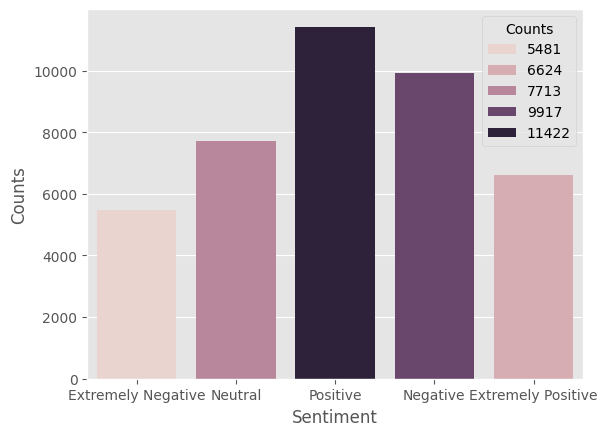

In [166]:
Plots=TextClassification(sentiment_data)
Plots.barplot_seaborn('Sentiment','Counts')

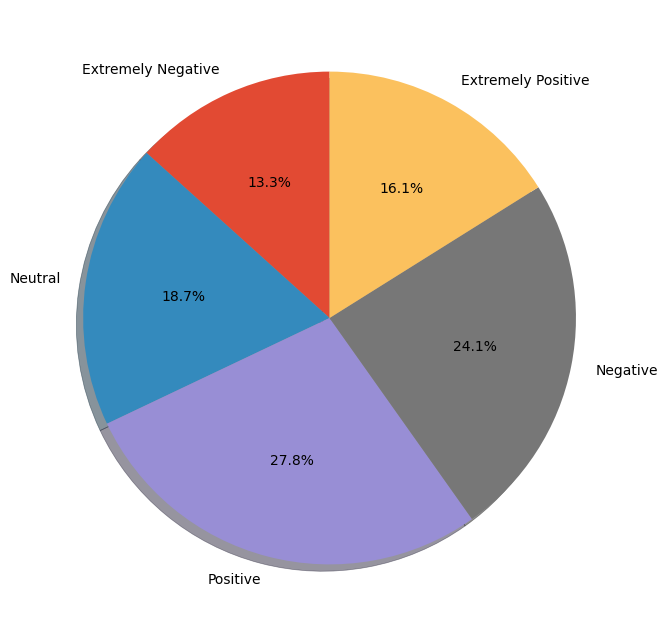

In [169]:
Plots.pie('Counts','Sentiment')

In [ ]:
# Correlation between Sentiment and Original Tweet
data_corr=training_data.select(pl.corr('OriginalTweet','Sentiment',method="spearman"))
data_corr

### World cloud plot

In [186]:
Plots=TextClassification(training_data)
Plots.WorldCloud()

AttributeError: 'TextClassification' object has no attribute 'training_data'